In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn

In [30]:
df = pd.read_csv("E:/ML/SolarProject/dataset/solar_data_khulna_from_jan_2014_to_nov_2022.csv")

df = df.dropna()
print(df.head())

   Year  Month  Day  Hour  Temperature  Irradiance
0  2014      1    1     6         9.44        0.00
1  2014      1    1     7        11.87       99.09
2  2014      1    1     8        14.55      290.91
3  2014      1    1     9        17.81      492.71
4  2014      1    1    10        21.96      647.74


In [31]:
df['datetime'] = pd.to_datetime(df.iloc[:,0])

df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

df = df[['hour','month','day','Temperature','Irradiance']]

In [32]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(df[['hour','month','day','Temperature']])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df[['Irradiance']])

In [33]:
df['class'] = pd.cut(
    df['Irradiance'],
    bins=[-1, 200, 600, df['Irradiance'].max()],
    labels=[0,1,2]
)

X_class = X_scaled
y_class = df['class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2)

In [34]:
clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train_c, y_train_c)

pred_c = clf.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, pred_c))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, pred_c))

Accuracy: 0.7183900691067315
Confusion Matrix:
 [[9318  757  119]
 [1865 1435  369]
 [ 487  804  474]]


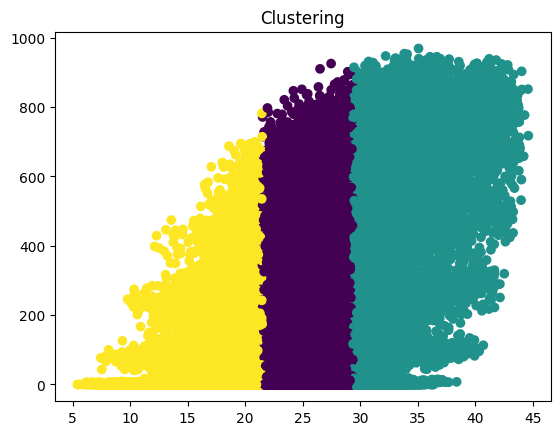

In [35]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

plt.scatter(df['Temperature'], df['Irradiance'], c=clusters)
plt.title("Clustering")
plt.savefig("E:/ML/SolarProject/results/clustering.png")
plt.show()

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

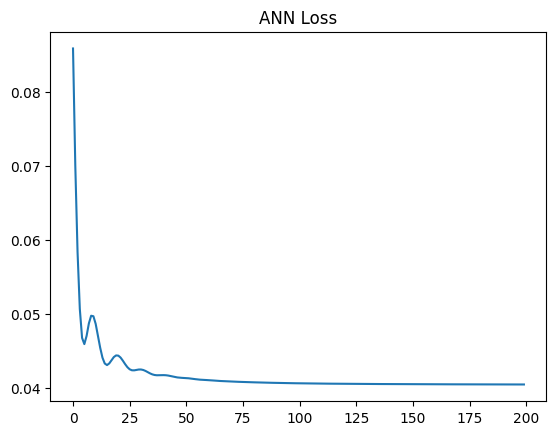

In [38]:
ann_model = nn.Sequential(
    nn.Linear(4,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,1)
).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(ann_model.parameters(), lr=0.001)

ann_losses = []

for epoch in range(200):
    optimizer.zero_grad()
    output = ann_model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    ann_losses.append(loss.item())

plt.plot(ann_losses)
plt.title("ANN Loss")
plt.savefig("E:/ML/SolarProject/results/ann_loss.png")
plt.show()

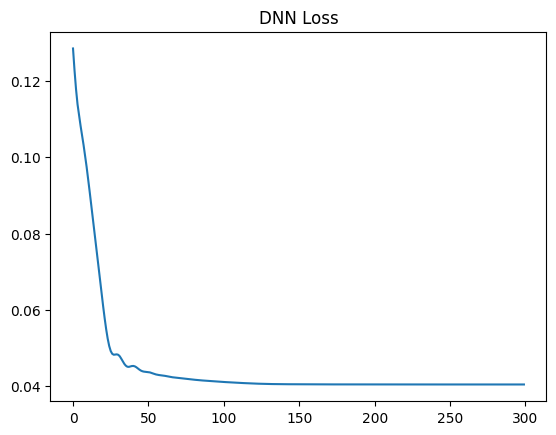

In [39]:
dnn_model = nn.Sequential(
    nn.Linear(4,256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
).to(device)

optimizer = torch.optim.Adam(dnn_model.parameters(), lr=0.0005)

dnn_losses = []

for epoch in range(300):
    optimizer.zero_grad()
    output = dnn_model(X_train)
    loss = loss_fn(output, y_train)
    loss.backward()
    optimizer.step()
    dnn_losses.append(loss.item())

plt.plot(dnn_losses)
plt.title("DNN Loss")
plt.savefig("E:/ML/SolarProject/results/dnn_loss.png")
plt.show()

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ANN
ann_pred = ann_model(X_test).detach().cpu().numpy()
y_true = y_test.detach().cpu().numpy()

ann_pred = scaler_y.inverse_transform(ann_pred)
y_true = scaler_y.inverse_transform(y_true)

ann_rmse = np.sqrt(mean_squared_error(y_true, ann_pred))

# DNN
dnn_pred = dnn_model(X_test).detach().cpu().numpy()
dnn_pred = scaler_y.inverse_transform(dnn_pred)

dnn_rmse = np.sqrt(mean_squared_error(y_true, dnn_pred))

print("ANN RMSE:", ann_rmse)
print("DNN RMSE:", dnn_rmse)

ANN RMSE: 192.26908837291032
DNN RMSE: 192.21349417704783


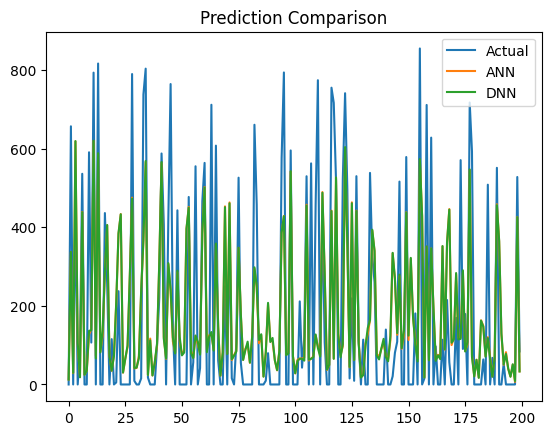

In [41]:
plt.plot(y_true[:200], label="Actual")
plt.plot(ann_pred[:200], label="ANN")
plt.plot(dnn_pred[:200], label="DNN")

plt.legend()
plt.title("Prediction Comparison")
plt.savefig("E:/ML/SolarProject/results/prediction.png")
plt.show()

In [42]:
comparison = pd.DataFrame({
    "Model": ["Classification", "ANN", "DNN"],
    "Metric": ["Accuracy", "RMSE", "RMSE"],
    "Value": [accuracy_score(y_test_c, pred_c), ann_rmse, dnn_rmse]
})

print(comparison)

            Model    Metric       Value
0  Classification  Accuracy    0.718390
1             ANN      RMSE  192.269088
2             DNN      RMSE  192.213494


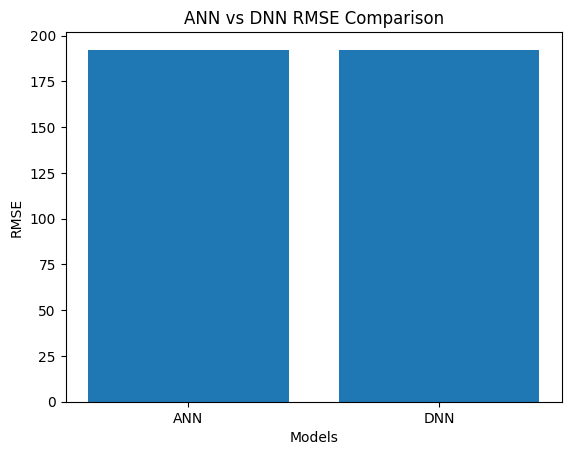

In [43]:
models = ["ANN", "DNN"]
rmse_values = [ann_rmse, dnn_rmse]

plt.figure()
plt.bar(models, rmse_values)
plt.title("ANN vs DNN RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.savefig("E:/ML/SolarProject/results/rmse_comparison.png")
plt.show()

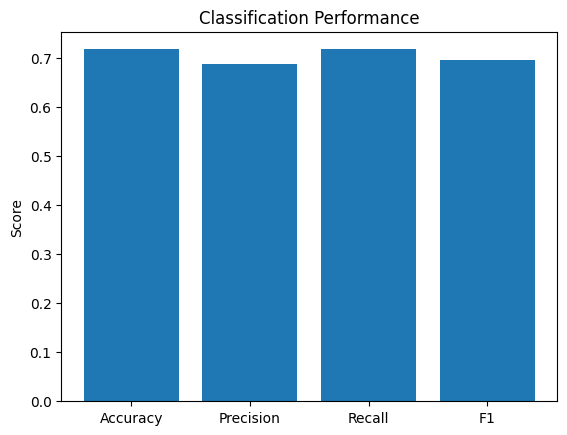

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_c, pred_c)
precision = precision_score(y_test_c, pred_c, average='weighted')
recall = recall_score(y_test_c, pred_c, average='weighted')
f1 = f1_score(y_test_c, pred_c, average='weighted')

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Classification Performance")
plt.ylabel("Score")
plt.savefig("E:/ML/SolarProject/results/classification_metrics.png")
plt.show()

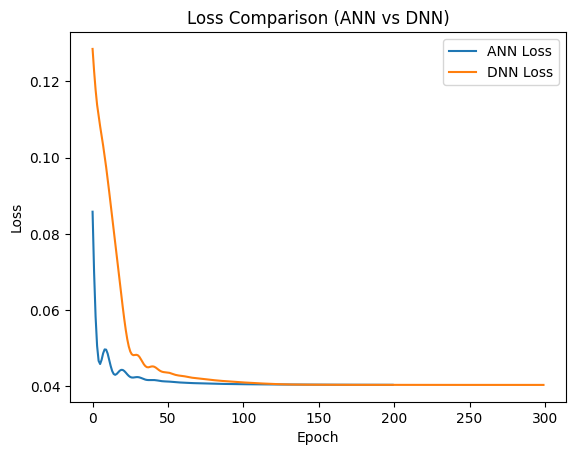

In [45]:
plt.figure()
plt.plot(ann_losses, label="ANN Loss")
plt.plot(dnn_losses, label="DNN Loss")
plt.legend()
plt.title("Loss Comparison (ANN vs DNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("E:/ML/SolarProject/results/loss_comparison.png")
plt.show()

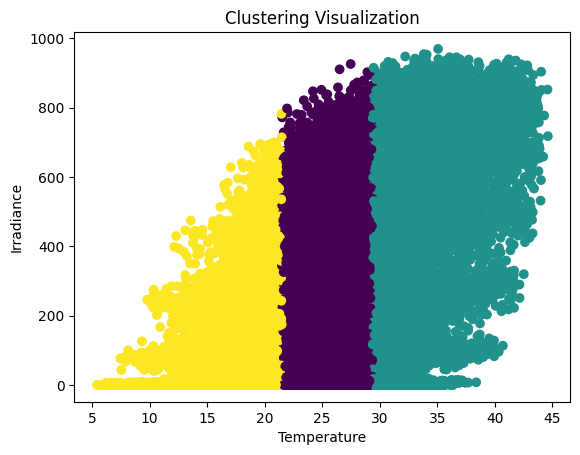

In [47]:
plt.figure()
plt.scatter(df['Temperature'], df['Irradiance'], c=df['cluster'], cmap='viridis')
plt.title("Clustering Visualization")
plt.xlabel("Temperature")
plt.ylabel("Irradiance")
plt.savefig("E:/ML/SolarProject/results/clustering_final.png")
plt.show()